# Mini Project 2 Notebook

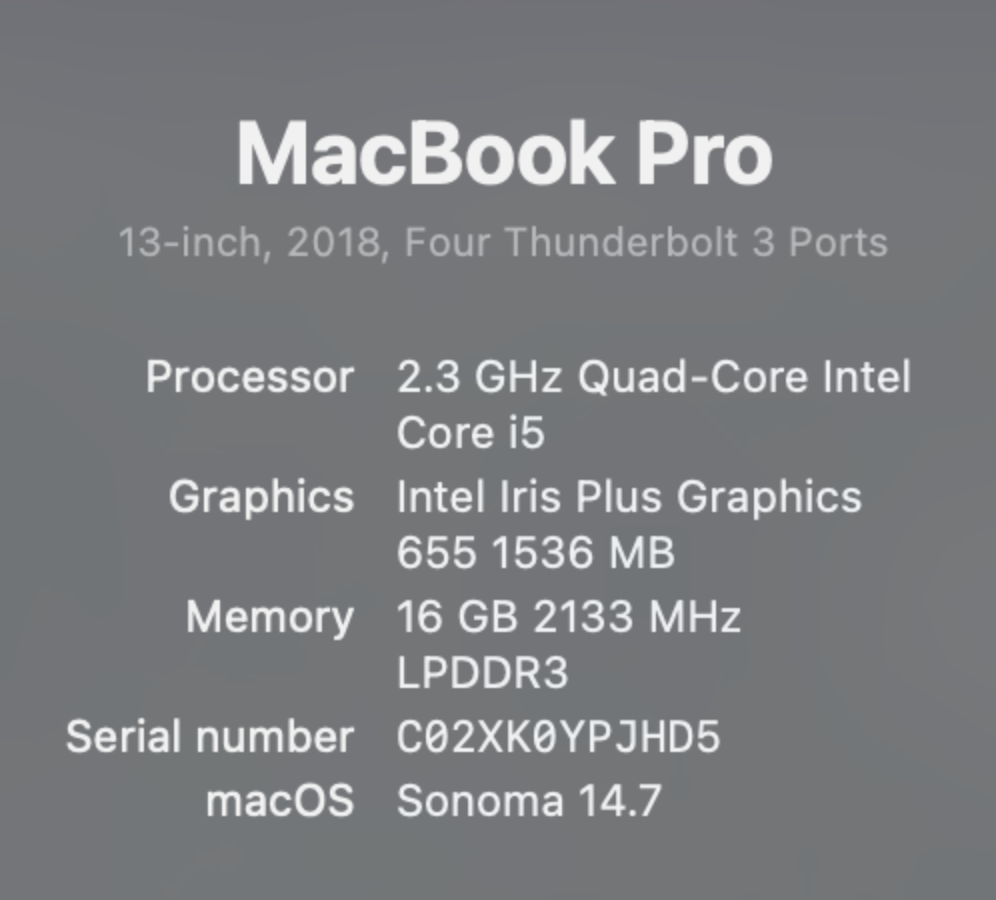

In [1]:
import numpy
import sys
import dask

print(sys.version)
print("Numpy version:", numpy.__version__)
print("Dask verson", dask.__version__)

3.14.3 | packaged by conda-forge | (main, Feb  5 2026, 05:57:55) [Clang 20.1.8 ]
Numpy version: 2.3.5
Dask verson 2026.1.2


### Measurement methodology
- 3 trials (4 if jit is involved as a warmup), take the median and report standard deviation.
- All multiprocessing runs are warmed up before timings

In [2]:
import pandas as pd

## Multiprocessing vs serial speedup

In [3]:
from main import w4_testing

_, median_serial, var_serial, medians = w4_testing(win_size=1024)

Benchmarking serial approach
Median execution time over 4 runs: 0.249990 seconds
Benchmarking parallel approach
Running on 1 cores
Median execution time over 3 runs for 1: 0.260126 seconds
Running on 2 cores
Median execution time over 3 runs for 2: 0.124272 seconds
Running on 3 cores
Median execution time over 3 runs for 3: 0.096412 seconds
Running on 4 cores
Median execution time over 3 runs for 4: 0.073271 seconds
Running on 5 cores
Median execution time over 3 runs for 5: 0.052196 seconds
Running on 6 cores
Median execution time over 3 runs for 6: 0.048719 seconds
Running on 7 cores
Median execution time over 3 runs for 7: 0.042567 seconds
Running on 8 cores
Median execution time over 3 runs for 8: 0.037642 seconds


In [4]:
import pandas as pd

df = pd.DataFrame(
    {
        "NoCore": range(1, 9),
        "medians": medians,
    }
)

# Calculate the speedup column
df["speedup"] = median_serial / df["medians"]

df

,NoCore,medians,speedup
0,1,0.260126,0.961032
1,2,0.124272,2.011626
2,3,0.096412,2.592938
3,4,0.073271,3.411845
4,5,0.052196,4.789440
5,6,0.048719,5.131285
6,7,0.042567,5.872892
7,8,0.037642,6.641171


Using the serial approach as a baseline, it can be seen that a speedup of 6.66 has been achieved using all 8 physical cores

## Multiprocessing LIF
Knowing that the optimal number of processers is 8 we use this for testing chunk sizes. 
Chunk sizes are calculated as number of processes multiplied by a value

In [5]:
from main import w5_chunk_testing

medians, LIFs, _ = w5_chunk_testing(win_size=1024, chunk_range=range(1, 17))

Median execution time over 4 runs: 0.241028 seconds
Execution time for 8 processes and 8 chunks: 0.032605 seconds and 0.082207 LIF
Execution time for 8 processes and 16 chunks: 0.017493 seconds and -0.419393 LIF
Execution time for 8 processes and 24 chunks: 0.011884 seconds and -0.605554 LIF
Execution time for 8 processes and 32 chunks: 0.009270 seconds and -0.692329 LIF
Execution time for 8 processes and 40 chunks: 0.008096 seconds and -0.731272 LIF
Execution time for 8 processes and 48 chunks: 0.008245 seconds and -0.726335 LIF
Execution time for 8 processes and 56 chunks: 0.008413 seconds and -0.720762 LIF
Execution time for 8 processes and 64 chunks: 0.017315 seconds and -0.425297 LIF
Execution time for 8 processes and 72 chunks: 0.010123 seconds and -0.664015 LIF
Execution time for 8 processes and 80 chunks: 0.008624 seconds and -0.713746 LIF
Execution time for 8 processes and 88 chunks: 0.009028 seconds and -0.700366 LIF
Execution time for 8 processes and 96 chunks: 0.008431 seco

In [6]:
df = pd.DataFrame([list(medians.keys()), list(medians.values()), list(LIFs.values())])
df_transposed = df.transpose()
df_transposed.columns = ["No. Chunks", "time", "LIF"]  # Rename the columns
df_transposed

df_transposed["vs x1"] = df_transposed["No. Chunks"] / 8  # Divide by 8
df_transposed["speedup"] = (
    median_serial / df_transposed["time"]
)  # Replace t_serial with your actual serial time
df_transposed

,No. Chunks,time,LIF,vs x1,speedup
0,8.0,0.032605,0.082207,1.0,7.667153
1,16.0,0.017493,-0.419393,2.0,14.290984
2,24.0,0.011884,-0.605554,3.0,21.035710
3,32.0,0.009270,-0.692329,4.0,26.968532
4,40.0,0.008096,-0.731272,5.0,30.876735
5,48.0,0.008245,-0.726335,6.0,30.319726
6,56.0,0.008413,-0.720762,7.0,29.714573
7,64.0,0.017315,-0.425297,8.0,14.437803
8,72.0,0.010123,-0.664015,9.0,24.695905
9,80.0,0.008624,-0.713746,10.0,28.986318


<Axes: title={'center': 'No Chunks vs speedup'}, xlabel='No. Chunks'>

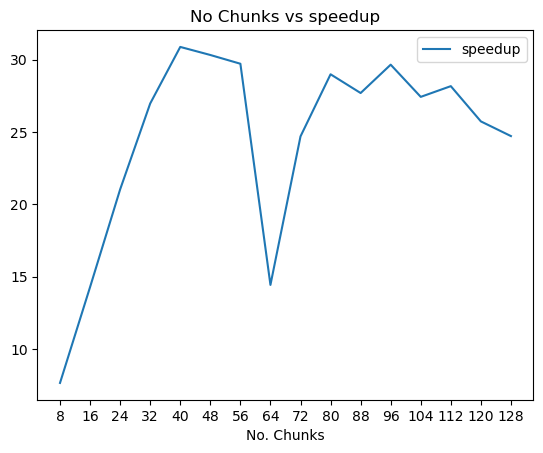

In [7]:
df_transposed.plot(
    x="No. Chunks",
    y="speedup",
    title="No Chunks vs speedup",
    xticks=range(1 * 8, 17 * 8, 8),
)

In [8]:
from main import benchmark_all

d = benchmark_all(n_runs=3)

Week 1: Naive python implementation
Execution took: 7.494663 seconds
Execution took: 7.746121 seconds
Execution took: 7.498151 seconds
Median execution time over 3 runs: 7.499270 seconds
Week 2: numpy vectorization
Execution took: 1.118900 seconds
Execution took: 1.134512 seconds
Execution took: 1.160153 seconds
Median execution time over 3 runs: 1.156357 seconds
Week 3: Naive numba
Execution took: 0.863841 seconds
Execution took: 0.643794 seconds
Execution took: 0.927877 seconds
Median execution time over 3 runs: 0.864066 seconds
Week 3: optimized numba
Execution took: 0.244810 seconds
Execution took: 0.081190 seconds
Execution took: 0.083639 seconds
Median execution time over 3 runs: 0.094418 seconds
Week 4: parallel computing
w4 median_w4 0.03312696000011783, 
w4 variance 1.7028248199372623e-07
Week 5: parallel computing with pools
Median execution time over 4 runs: 0.226214 seconds
Median time for w5: 0.01224089700008335, 
w5 variance 0.23076815634939996
Week 6: Dask local
Dashboar

In [9]:
df = pd.DataFrame(
    [
        d.get("w1_median"),
        d.get("w2_median"),
        d.get("w3_median"),
        d.get("w4_median"),
        d.get("w5_median"),
    ]
)
df.columns = ["Timings"]
df["Weeks"] = ["Naive", "Numpy", "numba", "Parallel", "Parallel Pooling"]
naive = df["Timings"][0]
df["Speedup"] = naive / df["Timings"]
df["LIF"] = [numpy.nan, numpy.nan, numpy.nan, numpy.nan, d.get("w5_LIF")]
df = df[["Weeks", "Timings", "Speedup", "LIF"]]
df

,Weeks,Timings,Speedup,LIF
0,Naive,7.499270,1.000000,NaN
1,Numpy,1.156357,6.485256,NaN
2,numba,0.094418,79.426693,NaN
3,Parallel,0.033127,226.379656,NaN
4,Parallel Pooling,0.012241,612.640546,-0.567104


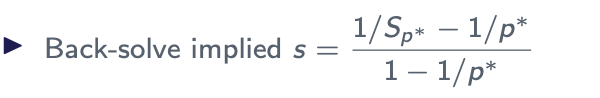

In [10]:
s4 = (1 / df["Speedup"][3] - 1 / 8) / (1 - 1 / 8)
s5 = (1 / df["Speedup"][4] - 1 / 8) / (1 - 1 / 8)
print(f"Parallel load balance: {s4}, parallel with pool load balance {s5}")

Parallel load balance: -0.1378087336452, parallel with pool load balance -0.14099168169869533


 - Through processor sweeping it has been found that 8 processors is always optimal. Through chunk sweeping it has been found that numbers around 48 or 6*processors is around optimal, although this can range between 4-8 for differing runs
 - parallelisation has been very worth it, giving over 600x increase in speedup vs naive on parallel with pooling and 200+ with a standard parallel approach

## Testing with chunksize with dask
Initially just test chunk sizes 8 - 1024 whilst doubling

In [11]:
from main import w6_testing
import pandas as pd

chunks = [8, 16, 32, 64, 128, 256, 512, 1024]
chunks, t_serial = w6_testing(win_size=4096, n_runs=5, testing_chunks=chunks)

Dashboard: http://127.0.0.1:8787/status
Execution for serial took: 4.272322 seconds
median time for dask worker: 0.6697835199997826
median time for dask worker: 0.3708074470000611
median time for dask worker: 0.2765878499999417
median time for dask worker: 0.25110122400019463
median time for dask worker: 0.3402182800000446
median time for dask worker: 0.7160968719999801
median time for dask worker: 1.0984103799996774
median time for dask worker: 2.2011046600000554


In [12]:
df = pd.DataFrame(chunks)
df_transposed = df.transpose()
df_transposed = df_transposed.reset_index()
df_transposed.columns = ["No. Chunks", "time", "LIF"]  # Rename the columns
df_transposed

df_transposed["vs x1"] = 8 / df_transposed["No. Chunks"]  # Divide by 8
df_transposed["speedup"] = t_serial / df_transposed["time"]
df_transposed

,No. Chunks,time,LIF,vs x1,speedup
0,8,0.669784,0.254182,1.000000,6.378661
1,16,0.370807,-0.305656,0.500000,11.521672
2,32,0.276588,-0.482084,0.250000,15.446527
3,64,0.251101,-0.529808,0.125000,17.014340
4,128,0.340218,-0.362935,0.062500,12.557590
5,256,0.716097,0.340904,0.031250,5.966123
6,512,1.098410,1.056793,0.015625,3.889550
7,1024,2.201105,3.121608,0.007812,1.940990


In [13]:
import numpy as np

chunks = np.linspace(16, 64, 7, dtype=int)
chunks, t_serial = w6_testing(win_size=4096, n_runs=5, testing_chunks=list(chunks))
df = pd.DataFrame(chunks)
df_transposed = df.transpose()
df_transposed = df_transposed.reset_index()
df_transposed.columns = ["No. Chunks", "time", "LIF"]  # Rename the columns
df_transposed

df_transposed["vs x1"] = df_transposed["No. Chunks"] / 8  # Divide by 8
df_transposed["speedup"] = (
    t_serial / df_transposed["time"]
)  # Replace t_serial with your actual serial time
df_transposed

Dashboard: http://127.0.0.1:8787/status
Execution for serial took: 4.331767 seconds
median time for dask worker: 0.372195425999962
median time for dask worker: 0.2877933730001132
median time for dask worker: 0.41946091299996624
median time for dask worker: 0.5055857690003904
median time for dask worker: 0.3998852029999398
median time for dask worker: 0.28635530699966694
median time for dask worker: 0.28596946900006515


,No. Chunks,time,LIF,vs x1,speedup
0,16,0.372195,-0.312622,2.0,11.638421
1,24,0.287793,-0.468497,3.0,15.051657
2,32,0.419461,-0.225331,4.0,10.326986
3,40,0.505586,-0.066273,5.0,8.567819
4,48,0.399885,-0.261483,6.0,10.832527
5,56,0.286355,-0.471153,7.0,15.127246
6,64,0.285969,-0.471865,8.0,15.147656


Document 1-16 chunks

<Axes: xlabel='No. Chunks'>

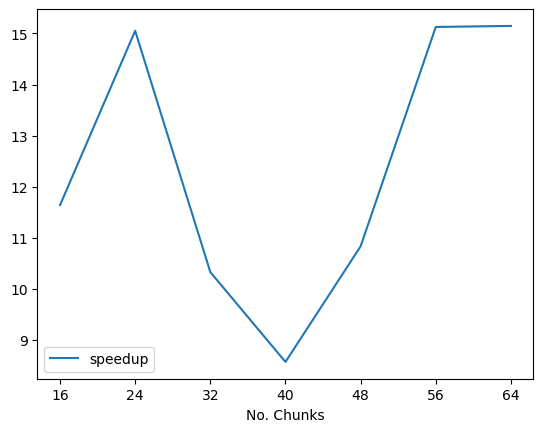

In [14]:
df_transposed.plot(
    x="No. Chunks", y="speedup", xticks=np.linspace(16, 64, 7, dtype=int)
)

The optimal speedup is  from 6-8x processors or 48-64, this often differs run to run, but the most optimal has been 48 overall

In [15]:
df = pd.DataFrame(
    [
        d.get("w1_median"),
        d.get("w2_median"),
        d.get("w3_median"),
        d.get("w4_median"),
        d.get("w5_median"),
        d.get("w6_median"),
    ]
)
df.columns = ["Timings"]
df["Weeks"] = ["Naive", "Numpy", "numba", "Parallel", "Parallel Pooling", "Dask local"]
naive = df["Timings"][0]
df["Speedup"] = naive / df["Timings"]
df["LIF"] = [
    numpy.nan,
    numpy.nan,
    numpy.nan,
    numpy.nan,
    d.get("w5_LIF"),
    d.get("w6_LIF"),
]
df = df[["Weeks", "Timings", "Speedup", "LIF"]]
df

,Weeks,Timings,Speedup,LIF
0,Naive,7.499270,1.000000,NaN
1,Numpy,1.156357,6.485256,NaN
2,numba,0.094418,79.426693,NaN
3,Parallel,0.033127,226.379656,NaN
4,Parallel Pooling,0.012241,612.640546,-0.567104
5,Dask local,0.117969,63.569695,3.299882


Dask local is worse in this case as we use a 1024 grid, it is shown to work better on larger grids

In [16]:
from main import bennchmark_parallel

f = bennchmark_parallel(size=4096)

Week 4: parallel computing
w4 median_w4 0.6211302649999197, 
w4 variance 0.0035899537286525744
Week 5: parallel computing with pools
Median execution time over 4 runs: 4.372470 seconds
Median time for w5: 0.3496710559998064, 
w5 variance 0.5885625897940536
Week 6: Dask local
Dashboard: http://127.0.0.1:8787/status
median time for dask worker: 0.2840740739998182
Execution for serial took: 4.433045 seconds
Median time for w6: 0.2840740739998182, 
w6 variance 0.0011743610199798622


In [17]:
df = pd.DataFrame([f.get("w4_median"), f.get("w5_median"), f.get("w6_median")])
df.columns = ["Timings"]
df["Weeks"] = ["Parallel", "Parallel Pooling", "Dask local"]
naive = t_serial  # Benchmark from serial time
df["Speedup"] = naive / df["Timings"]
df["LIF"] = [numpy.nan, d.get("w5_LIF"), d.get("w6_LIF")]
df = df[["Weeks", "Timings", "Speedup", "LIF"]]
df

,Weeks,Timings,Speedup,LIF
0,Parallel,0.621130,6.974008,NaN
1,Parallel Pooling,0.349671,12.388120,-0.567104
2,Dask local,0.284074,15.248724,3.299882


We can see that there is an increase in speedup when using a larger mandelbrot size

Testing to see the difference in speedup for normal pooling vs dask distributed

Median execution time over 4 runs: 0.067967 seconds
Dashboard: http://127.0.0.1:8787/status
median time for dask worker: 0.13772856400009914
Execution for serial took: 0.062706 seconds
Median execution time over 4 runs: 0.230885 seconds
Dashboard: http://127.0.0.1:8787/status
median time for dask worker: 0.13349136999931943
Execution for serial took: 0.231598 seconds
Median execution time over 4 runs: 0.924330 seconds
Dashboard: http://127.0.0.1:8787/status
median time for dask worker: 0.15182740799991734
Execution for serial took: 1.045518 seconds
Median execution time over 4 runs: 3.800762 seconds
Dashboard: http://127.0.0.1:8787/status
median time for dask worker: 0.3698177240003133
Execution for serial took: 3.765612 seconds
Median execution time over 4 runs: 15.499061 seconds
Dashboard: http://127.0.0.1:8787/status
median time for dask worker: 0.786907450000399
Execution for serial took: 14.656991 seconds
Median execution time over 4 runs: 60.327445 seconds
Dashboard: http://127.0

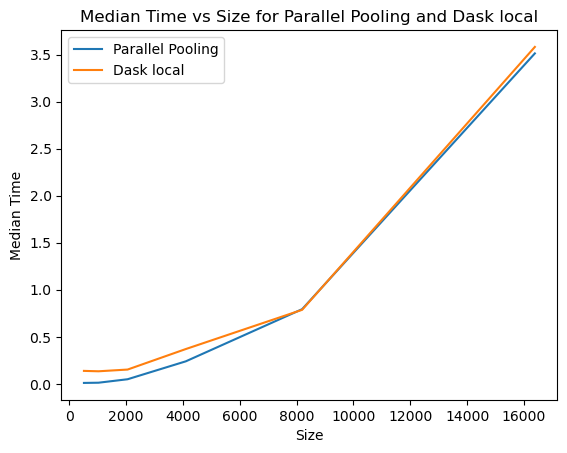

In [6]:
from main import w6_main, w5_main
import matplotlib.pyplot as plt

medians_w5 = []
medians_w6 = []
for size in [512, 1024, 2048, 4096, 8192, 16384]:
    median_parallel_w5, _, _, _ = w5_main(100, (-2.0, 1.0), (-1.5, 1.5), size, n_runs=3)
    median_parallel, _, _, _ = w6_main(100, (-2.0, 1.0), (-1.5, 1.5), size, n_runs=3)
    medians_w5.append(median_parallel_w5)
    medians_w6.append(median_parallel)
plt.plot([512, 1024, 2048, 4096, 8192, 16384], medians_w5, label="Parallel Pooling")
plt.plot([512, 1024, 2048, 4096, 8192, 16384], medians_w6, label="Dask local")
plt.xlabel("Size")
plt.ylabel("Median Time")
plt.title("Median Time vs Size for Parallel Pooling and Dask local")
plt.legend()
plt.show()

## Dask distributed
All results on 4 cores over 2 machines

![Screenshot 2026-03-26 at 15.38.54.png](<attachment:Screenshot 2026-03-26 at 15.38.54.png>)
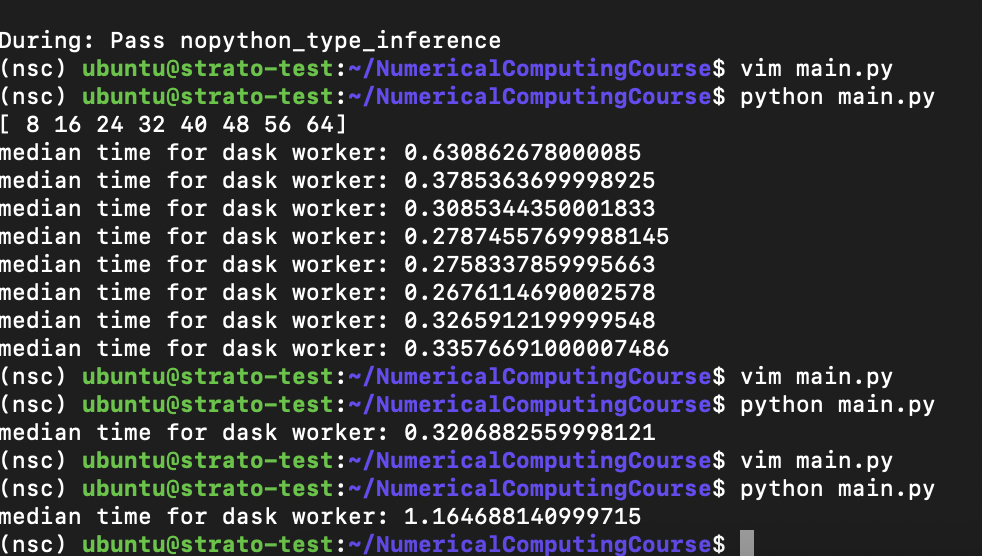

On a 4096 grid, the best number of chunks is 48

![Screenshot 2026-03-26 at 15.44.23.png](<attachment:Screenshot 2026-03-26 at 15.44.23.png>)
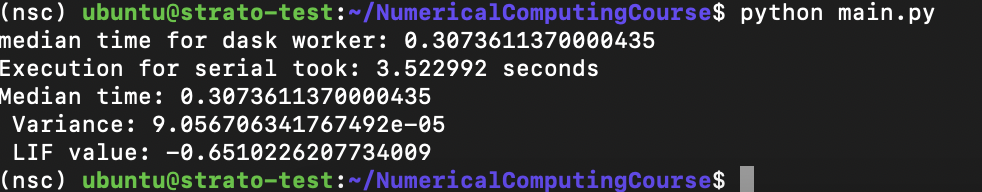

Timings on a 4096 grid with chunksize 48

In [18]:
dask_distributed_median_time = 0.30736
dask_distributed_LIF = -0.651
dask_distributed_serial = 3.523
df.loc[len(df)] = [
    "Dask distributed (4cores)",
    dask_distributed_median_time,
    dask_distributed_serial / dask_distributed_median_time,
    dask_distributed_LIF,
]

In [19]:
df

,Weeks,Timings,Speedup,LIF
0,Parallel,0.621130,6.974008,NaN
1,Parallel Pooling,0.349671,12.388120,-0.567104
2,Dask local,0.284074,15.248724,3.299882
3,Dask distributed (4cores),0.307360,11.462129,-0.651000


it can be see that dask distributed had less of a speedup, but this is primarily due to having less cores than the local approach

## Overall speedup 
Using 4096 size for better comparison

In [ ]:
from main import benchmark_all

d = benchmark_all(n_runs=3, size=4096)

In [4]:
import pandas as pd
import numpy

df = pd.DataFrame(
    [
        d.get("w1_median"),
        d.get("w2_median"),
        d.get("w3_median"),
        d.get("w4_median"),
        d.get("w5_median"),
        d.get("w6_median"),
    ]
)
df.columns = ["Timings"]
df["Weeks"] = ["Naive", "Numpy", "numba", "Parallel", "Parallel Pooling", "Dask local"]
naive = df["Timings"][0]
df["Speedup"] = naive / df["Timings"]
df["LIF"] = [
    numpy.nan,
    numpy.nan,
    numpy.nan,
    numpy.nan,
    d.get("w5_LIF"),
    d.get("w6_LIF"),
]
df = df[["Weeks", "Timings", "Speedup", "LIF"]]
df

,Weeks,Timings,Speedup,LIF
0,Naive,123.111210,1.000000,NaN
1,Numpy,26.499864,4.645730,NaN
2,numba,1.991145,61.829342,NaN
3,Parallel,0.600701,204.945740,NaN
4,Parallel Pooling,0.361730,340.340338,-0.299471
5,Dask local,0.286857,429.173181,-0.420306


## Reflections

- Timing differences differed,I timed without overhead and he timed with overhead included. Made a large difference to speedup
- Up to parallel results were similar, slightly less speedup for numpy than expected but plausible. Parallel differed largely with me not measuring pooling overhead. Best chunksize also differed a lot. 
- More graphs / tables for dask cluster and checking chunksize < 8
- Follow the recommendations in the slides for what needs to be output 